## Install & import

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,f1_score,roc_curve, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

## Load datasets

In [9]:
#from google.colab import drive
#drive.mount('/content/drive')

In [10]:
#alz = pd.read_csv('/content/drive/MyDrive/OZP_datasets/alzheimers_disease_data.csv')
#dia = pd.read_csv('/content/drive/MyDrive/OZP_datasets/diabetes_binary_health_indicators_BRFSS2015.csv')

alz = pd.read_csv("https://raw.githubusercontent.com/TLm0n/Thesis_classification_algorithms/main/alzheimers_disease_data.csv")
dia = pd.read_csv("https://raw.githubusercontent.com/TLm0n/Thesis_classification_algorithms/main/diabetes_binary_health_indicators_BRFSS2015.csv")

print(f"Alzheimer's dataset: {alz.shape[0]} rows, {alz.shape[1]} columns")
print(f"Diabetes dataset:    {dia.shape[0]} rows, {dia.shape[1]} columns")

Alzheimer's dataset: 2149 rows, 35 columns
Diabetes dataset:    253680 rows, 22 columns


In [11]:
print(alz.head())
print(f'\nNull values: {alz.isnull().sum().sum()}\n')
print(alz['Diagnosis'].value_counts())
print(alz['Diagnosis'].value_counts(normalize=True))

   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientation  \
0     

In [12]:
print(dia.head())
print(f'\nNull values: {dia.isnull().sum().sum()}\n')
print(dia['Diabetes_binary'].value_counts())
print(dia['Diabetes_binary'].value_counts(normalize=True))

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

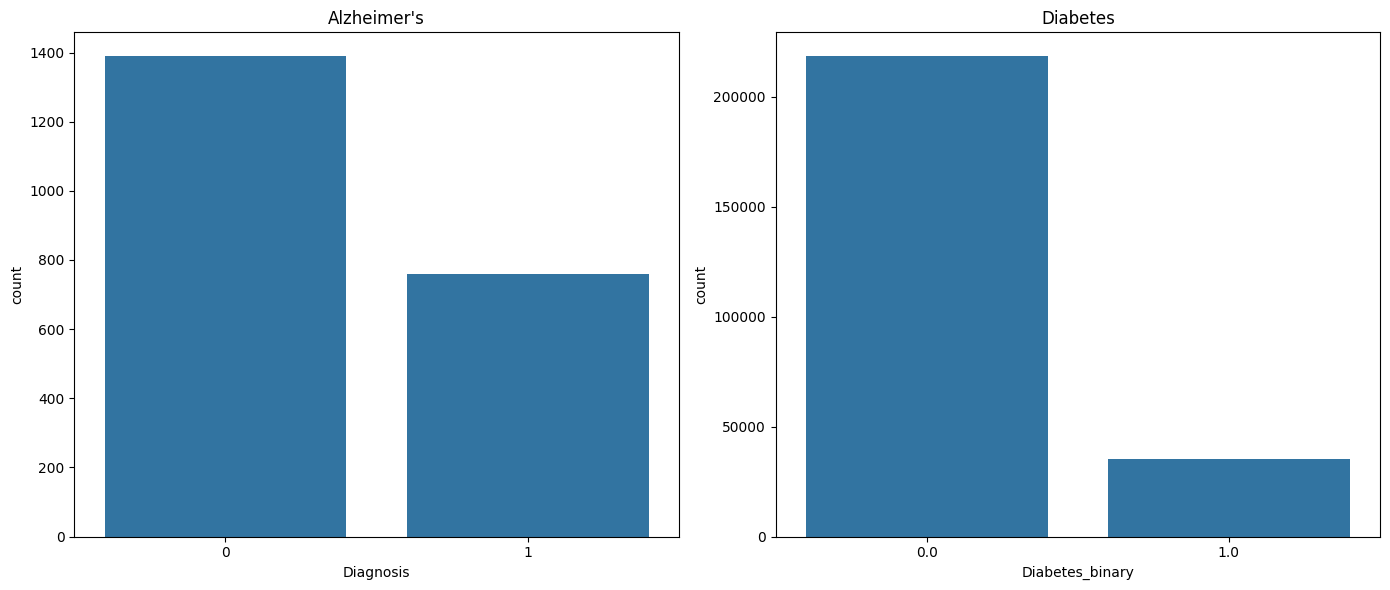

In [13]:
# Positive and negative cases class distribution for each dataset (absolute numbers)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=alz, x='Diagnosis', ax=axes[0])
axes[0].set_title('Alzheimer\'s')

sns.countplot(data=dia, x='Diabetes_binary', ax=axes[1])
axes[1].set_title('Diabetes')

plt.tight_layout()
plt.show()

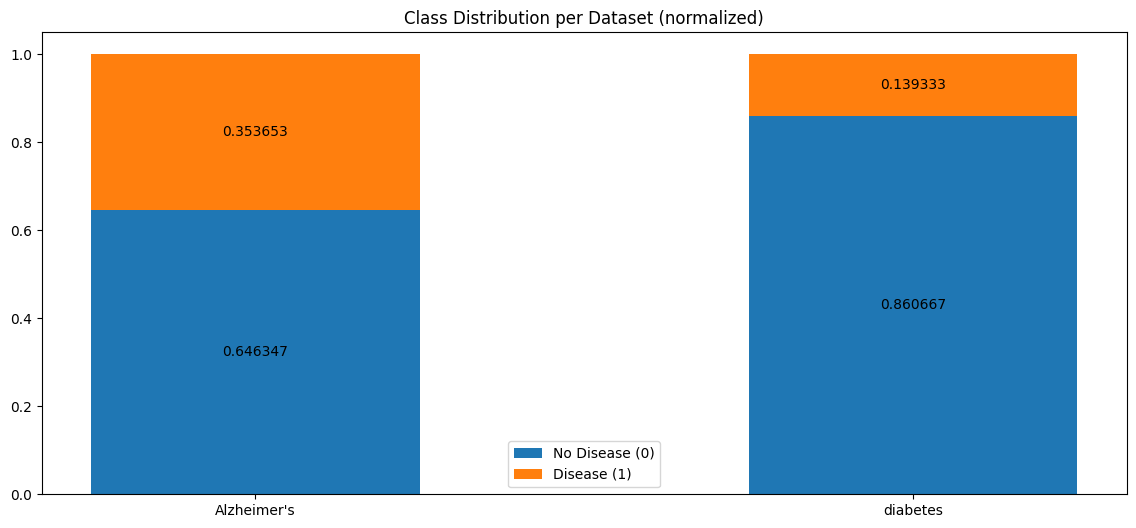

In [45]:
# Positive and negative cases class distribution for each dataset (normalized)
fig, ax = plt.subplots(figsize=(14, 6))

counts = {
    'No Disease (0)': np.array([
        alz['Diagnosis'].value_counts(normalize=True)[0],
        dia['Diabetes_binary'].value_counts(normalize=True)[0]
    ]),
    'Disease (1)': np.array([
        alz['Diagnosis'].value_counts(normalize=True)[1],
        dia['Diabetes_binary'].value_counts(normalize=True)[1]
    ])
}

datasets = ('Alzheimer\'s', 'diabetes')
bottom = np.zeros(2)

for label, count in counts.items():
    bars = ax.bar(datasets, count, width=0.5, label=label, bottom=bottom)
    bottom += count
    ax.bar_label(bars, label_type='center')

ax.set_title('Class Distribution per Dataset (normalized)')
ax.legend()
plt.show()

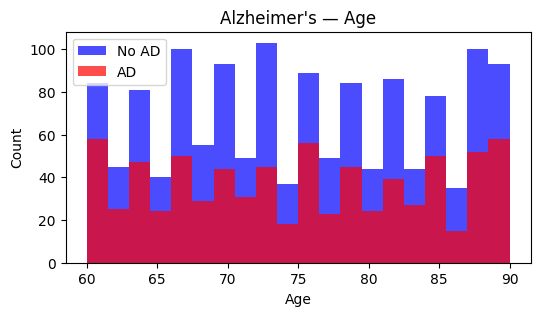

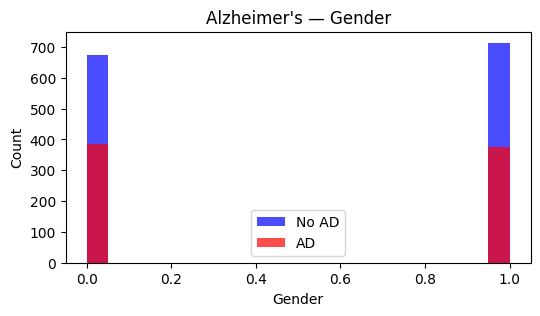

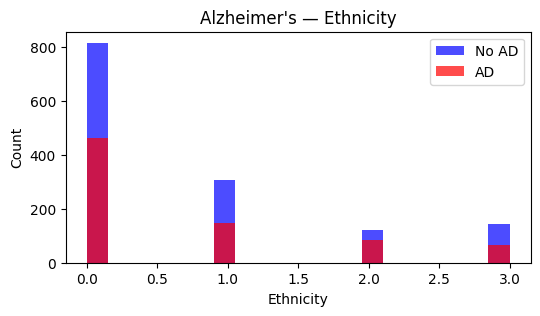

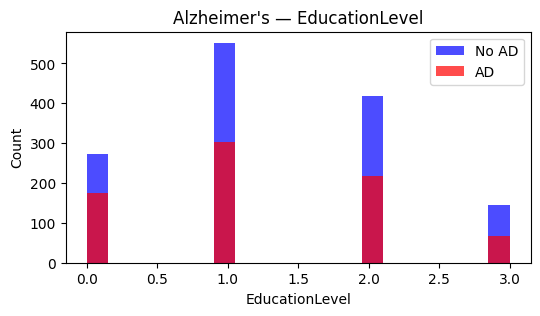

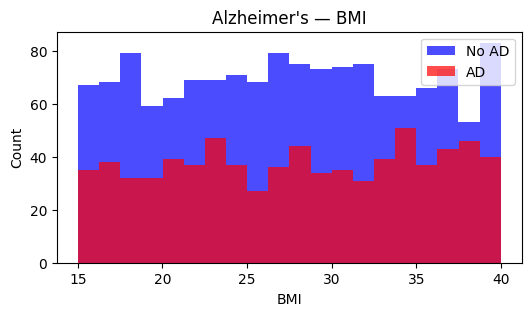

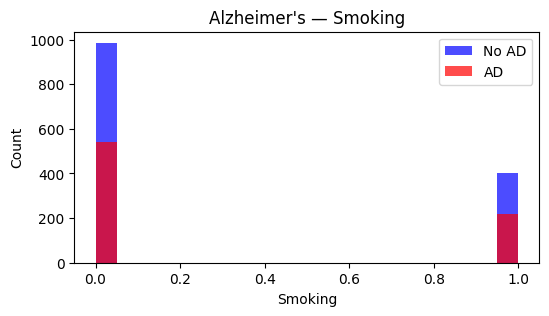

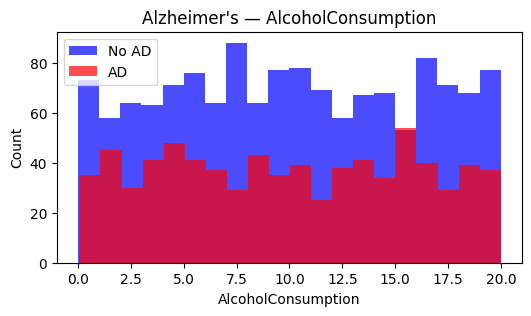

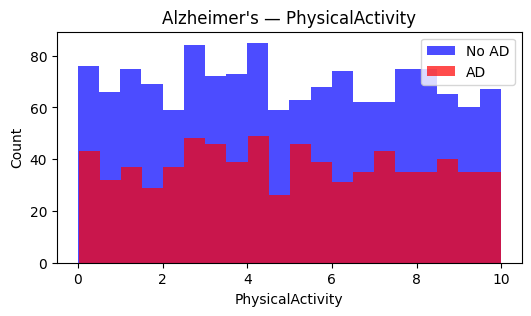

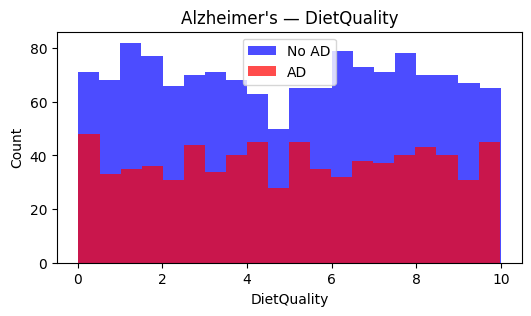

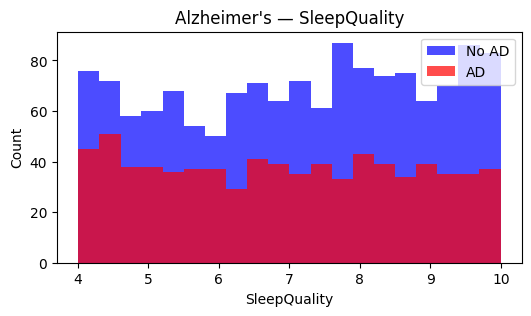

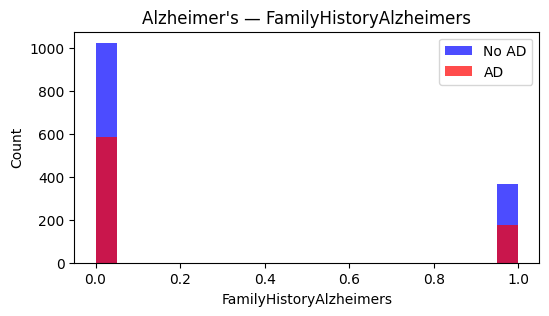

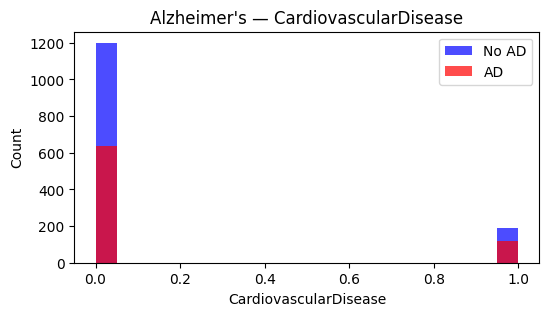

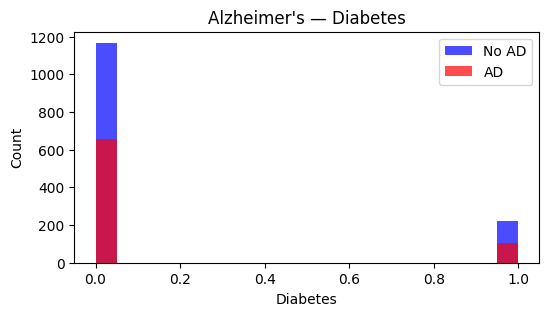

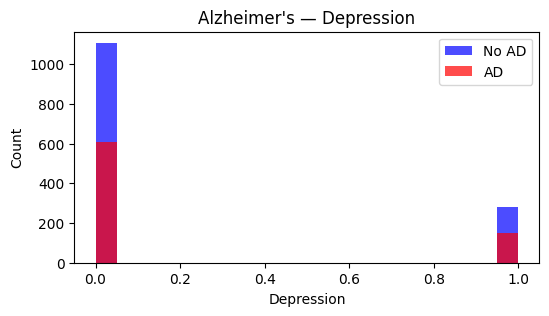

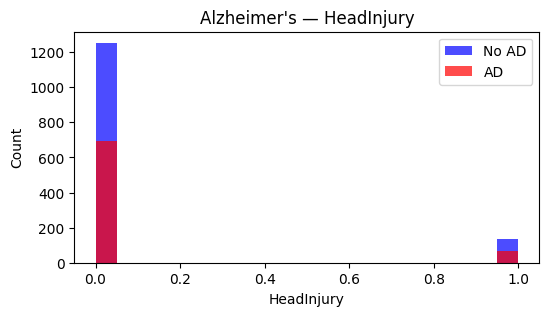

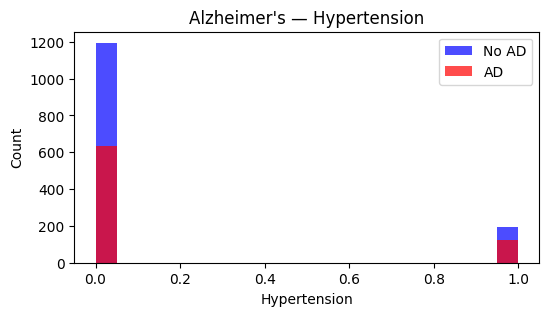

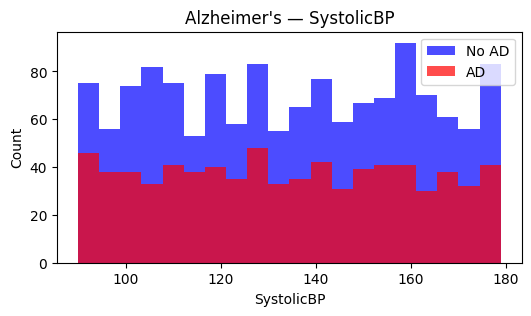

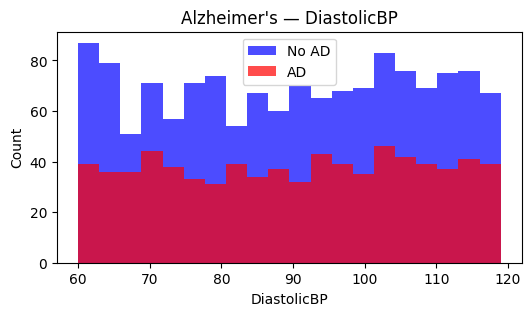

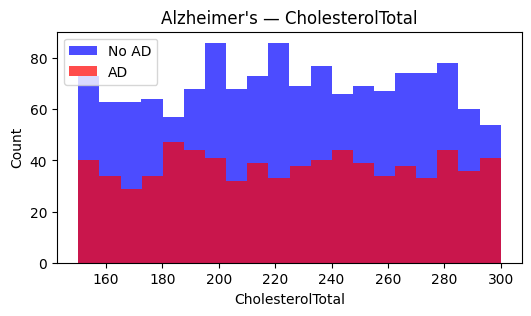

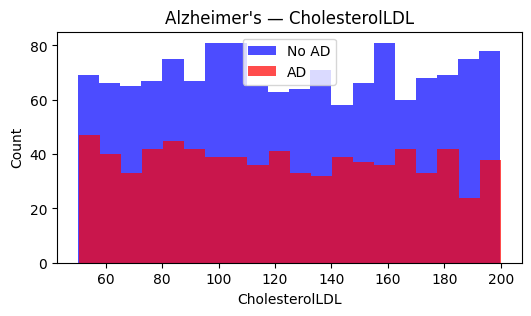

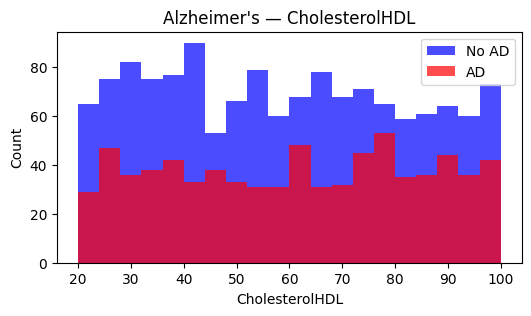

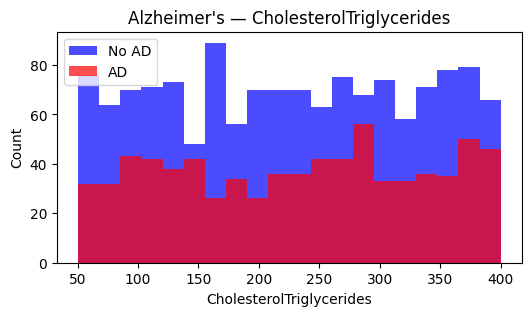

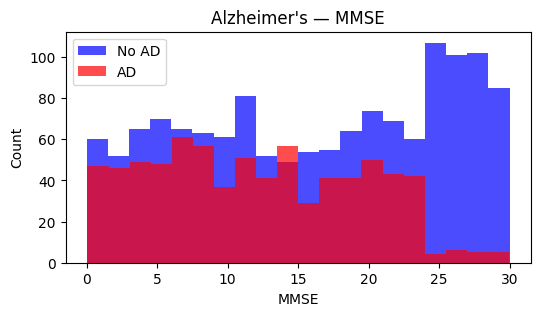

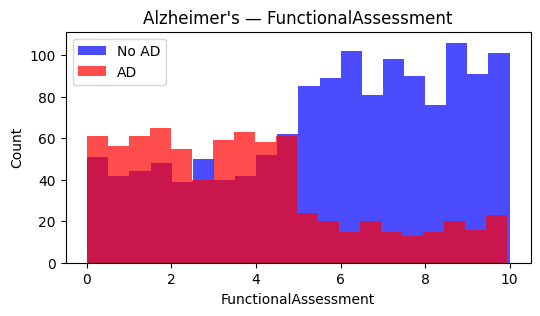

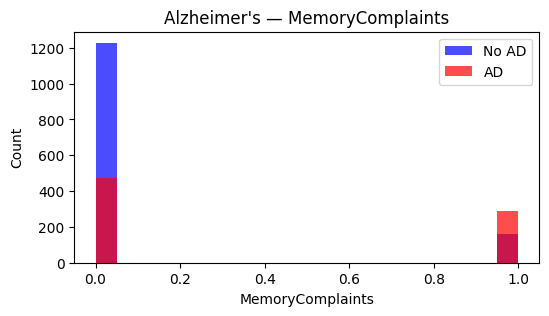

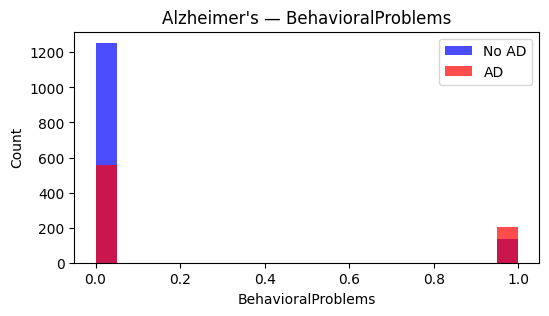

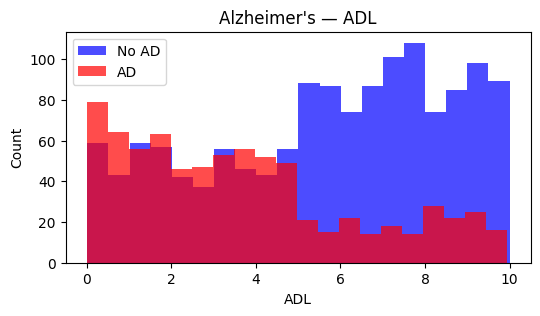

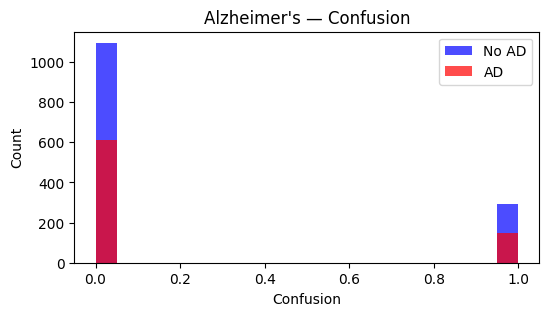

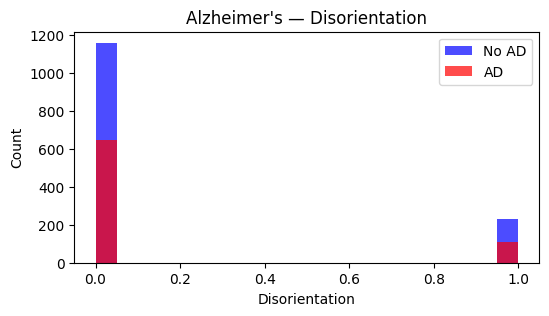

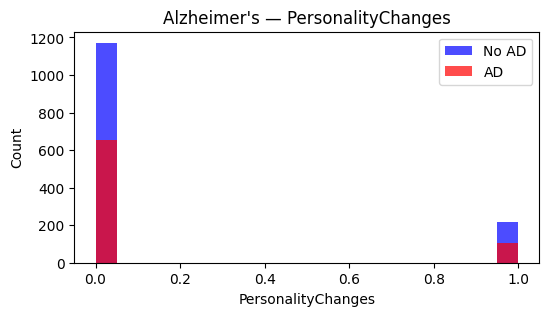

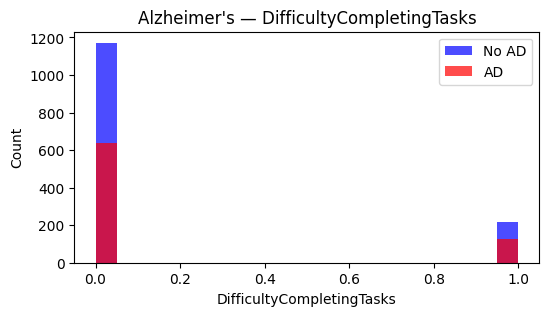

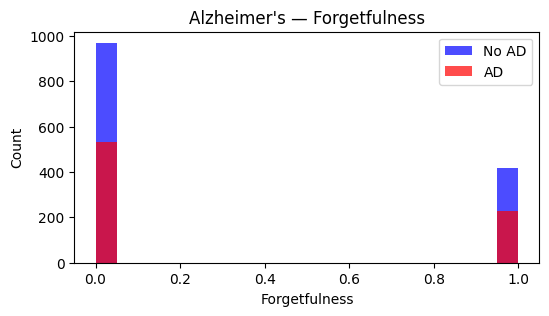

In [15]:
# Alzheimer's feature distributions
for label in alz.drop(columns=['PatientID', 'DoctorInCharge', 'Diagnosis']).columns:
    plt.figure(figsize=(6, 3))
    plt.hist(alz[alz['Diagnosis'] == 0][label], color='blue', bins=20, alpha=0.7, label='No AD')
    plt.hist(alz[alz['Diagnosis'] == 1][label], color='red', bins=20, alpha=0.7, label='AD')
    plt.title(f"Alzheimer's — {label}")
    plt.xlabel(label)
    plt.ylabel('Count')
    plt.legend()
    plt.show()

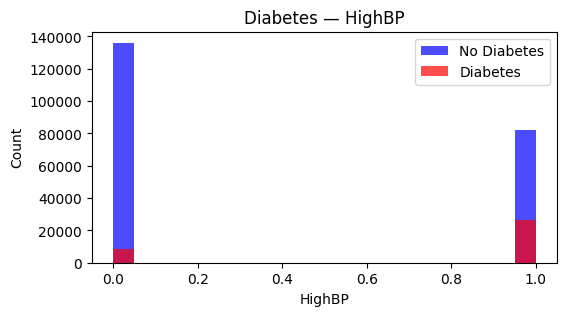

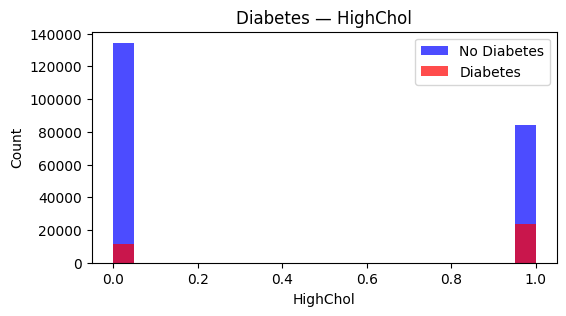

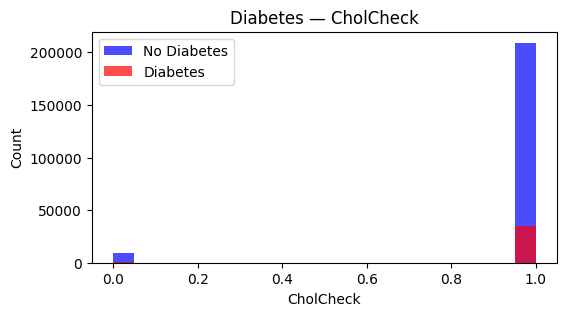

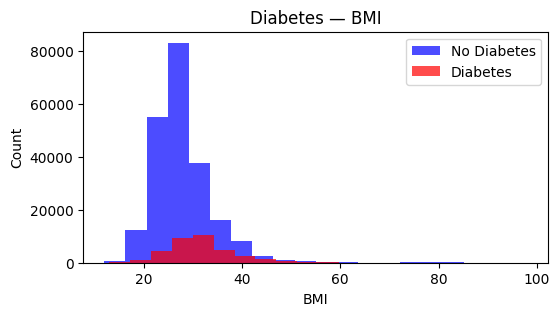

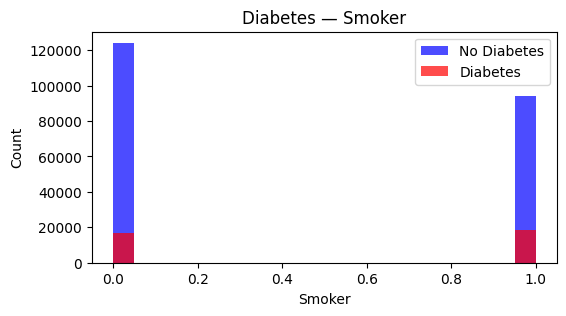

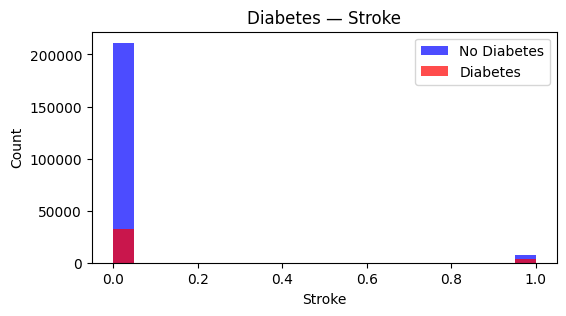

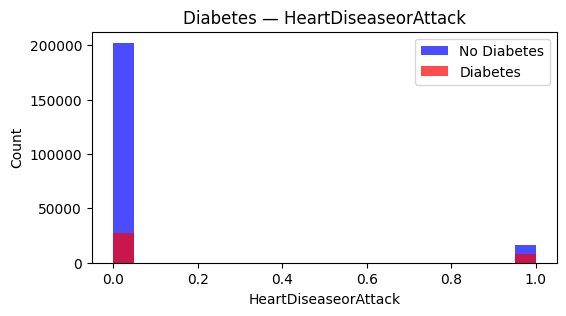

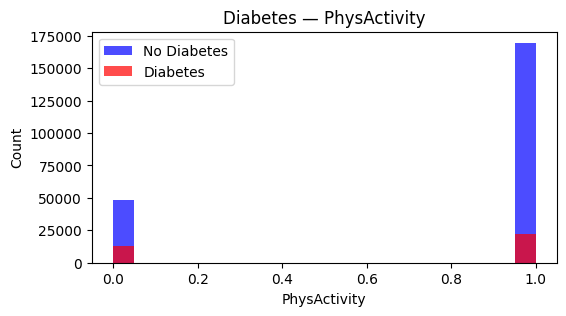

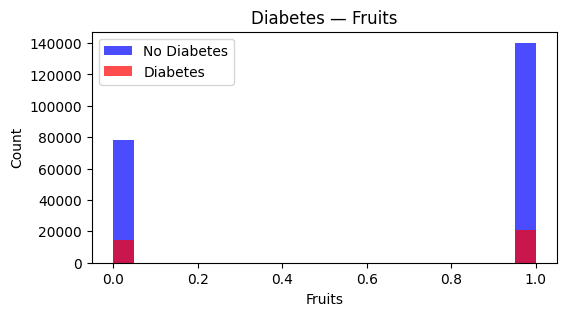

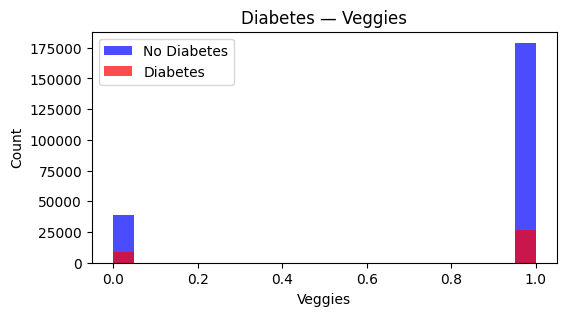

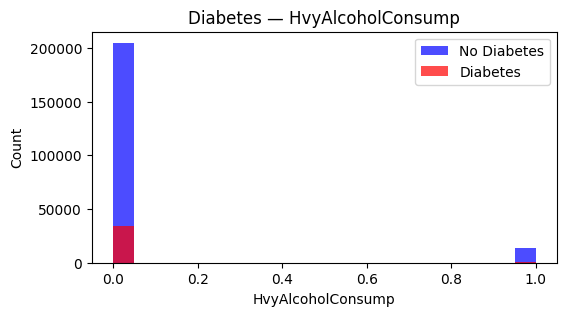

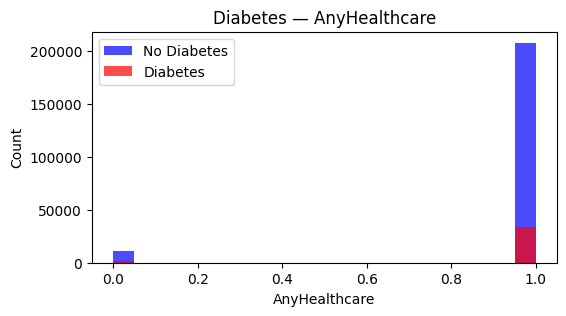

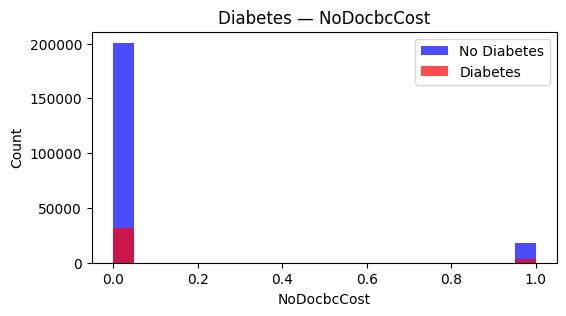

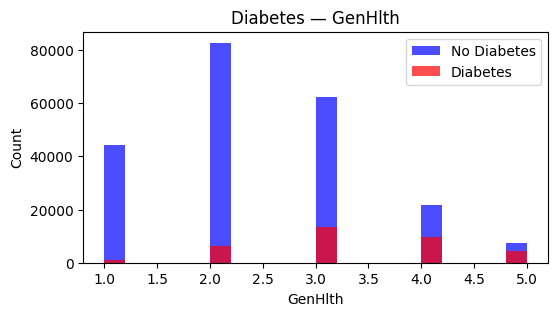

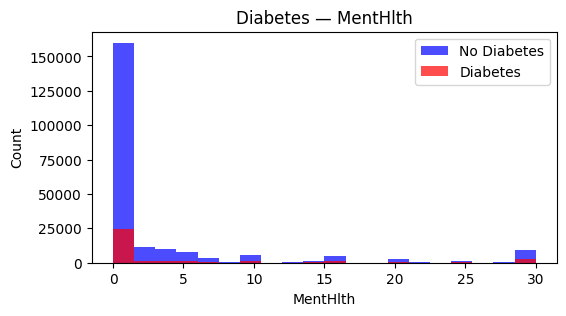

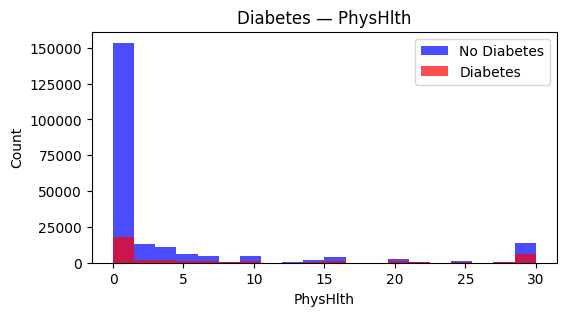

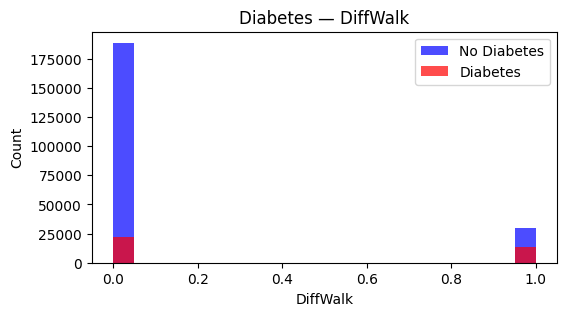

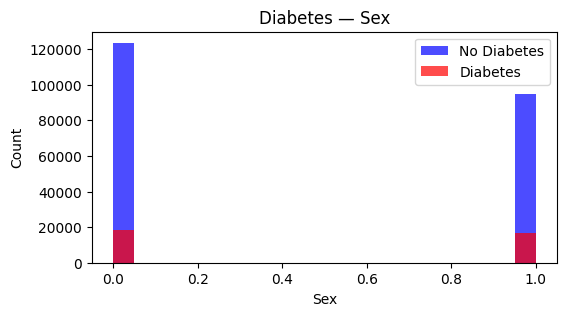

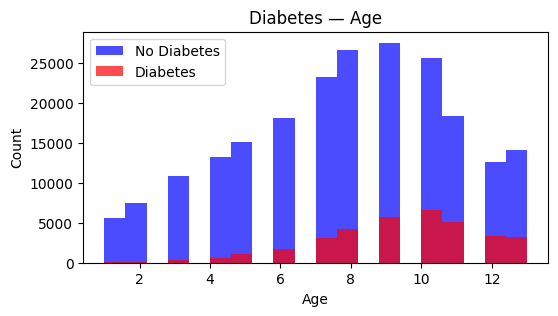

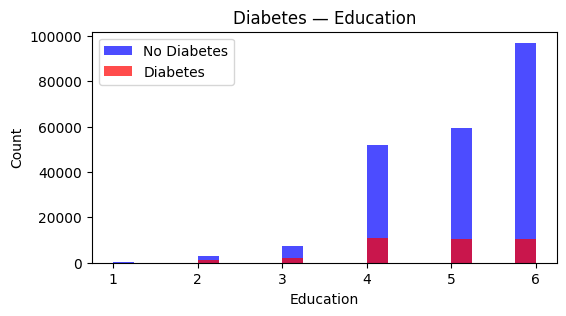

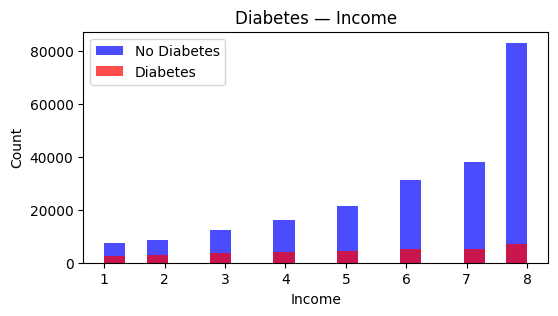

In [16]:
# Diabetes feature distributions
for label in dia.drop(columns=['Diabetes_binary']).columns:
    plt.figure(figsize=(6, 3))
    plt.hist(dia[dia['Diabetes_binary'] == 0][label], color='blue', bins=20, alpha=0.7, label='No Diabetes')
    plt.hist(dia[dia['Diabetes_binary'] == 1][label], color='red', bins=20, alpha=0.7, label='Diabetes')
    plt.title(f"Diabetes — {label}")
    plt.xlabel(label)
    plt.ylabel('Count')
    plt.legend()
    plt.show()

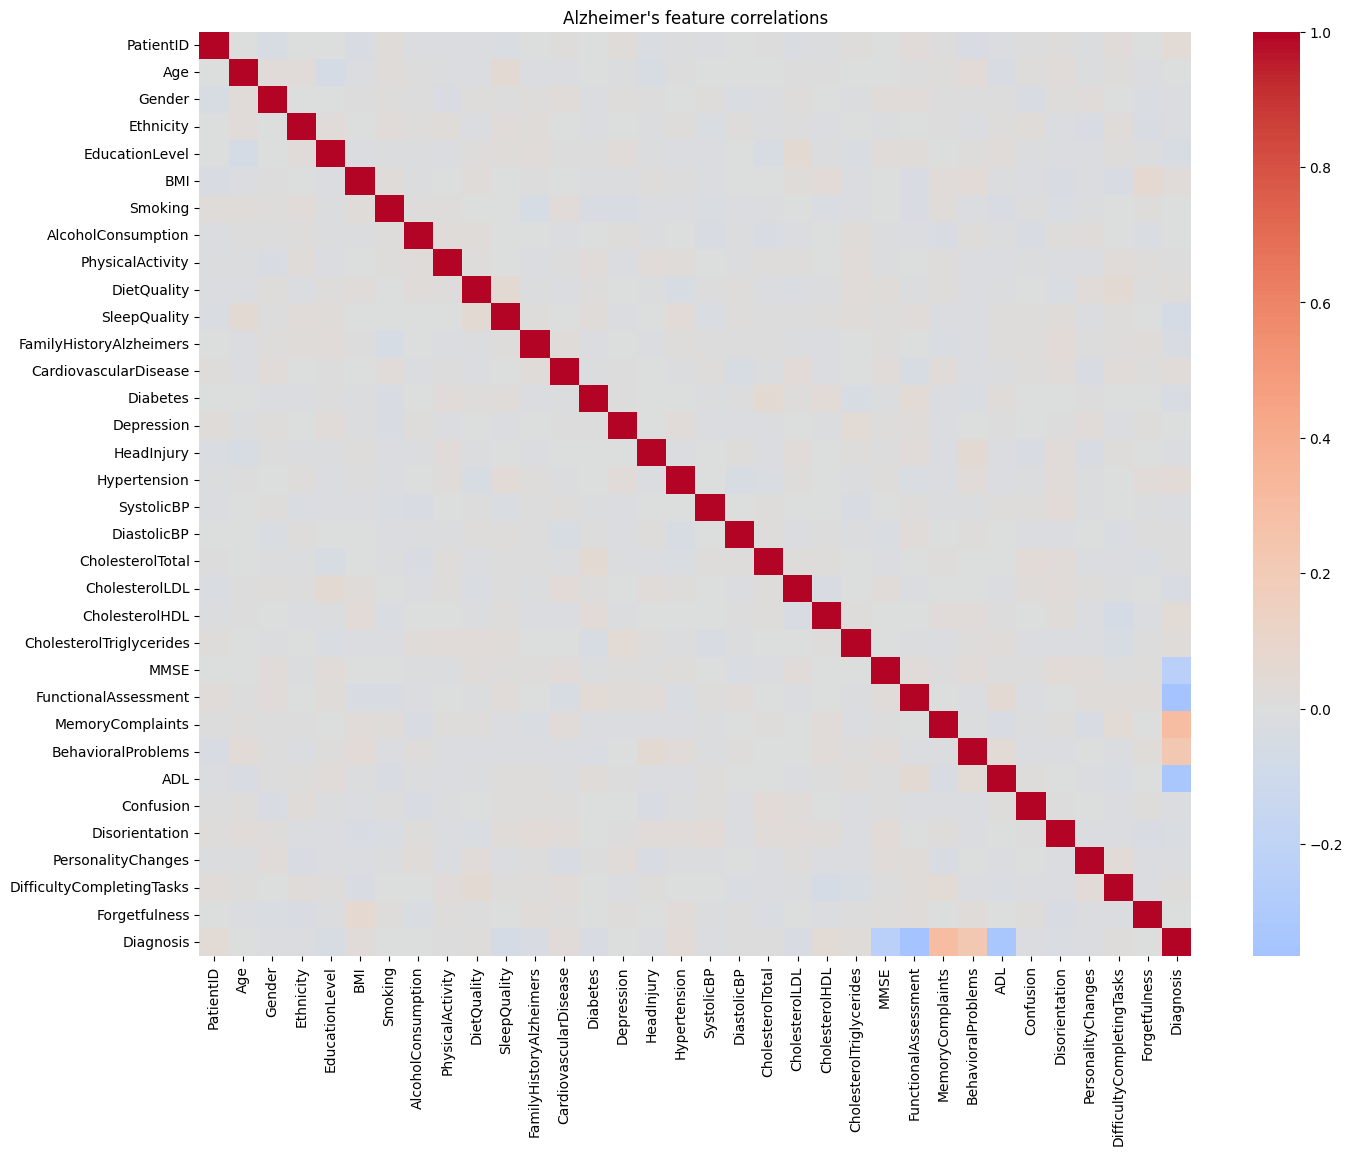

In [17]:
# Alzheimer's correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(alz.select_dtypes(include='number').corr(), cmap='coolwarm', center=0)
plt.title("Alzheimer's feature correlations")
plt.show()

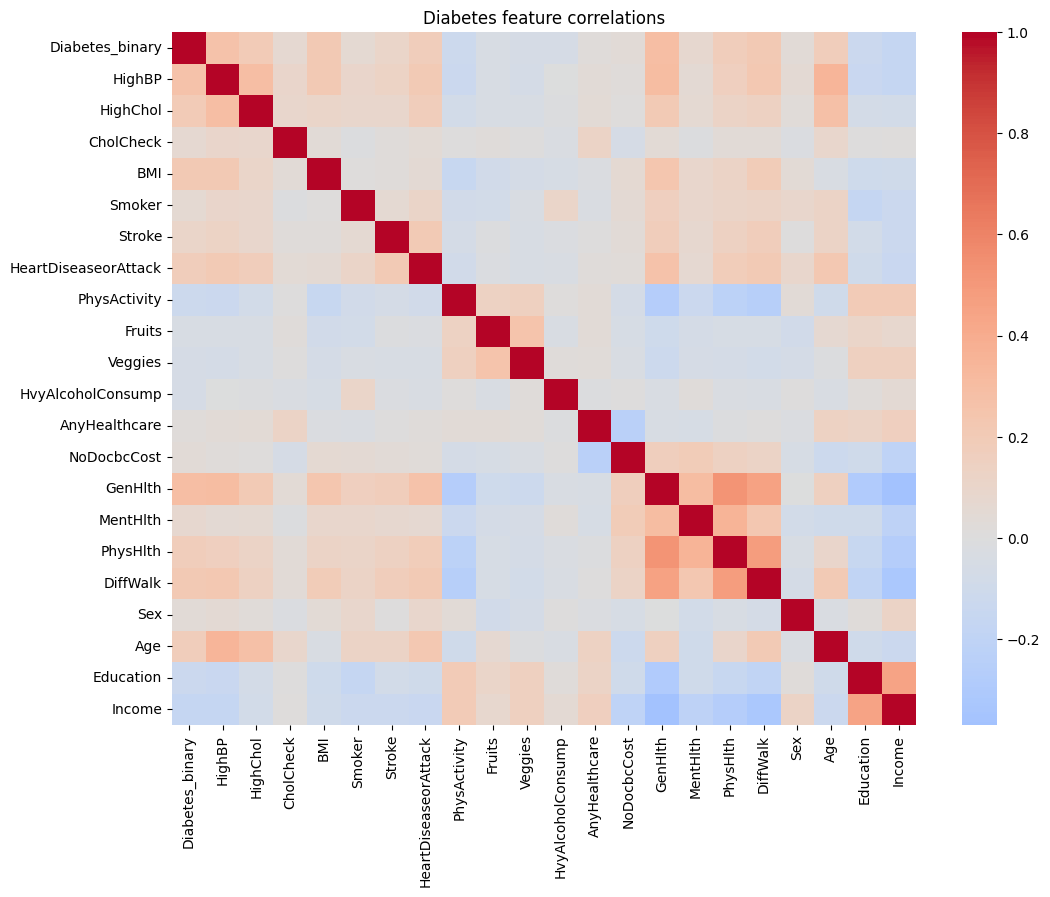

In [18]:
# Diabetes correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(dia.corr(), cmap='coolwarm', center=0)
plt.title("Diabetes feature correlations")
plt.show()

## Data preparaton

In [19]:
# Make the randomstate a variable for consistency
RS = 42

In [20]:
# Alzheimer's data preparation
alz_prep = alz.drop(columns=['PatientID', 'DoctorInCharge'])

X_alz = alz_prep.drop(columns=['Diagnosis'])
y_alz = alz_prep['Diagnosis']
alz_features = X_alz.columns.tolist()

X_train_alz, X_test_alz, y_train_alz, y_test_alz = train_test_split(
    X_alz, y_alz, test_size=0.2, random_state=RS, stratify=y_alz
)

alz_scaler = StandardScaler()
X_train_alz = alz_scaler.fit_transform(X_train_alz)
X_test_alz  = alz_scaler.transform(X_test_alz)

print(f"Alzheimer's: training set: {len(X_train_alz)} and testing set: {len(X_test_alz)}")


Alzheimer's: training set: 1719 and testing set: 430


In [21]:
# Diabetes data preparation
X_dia = dia.drop(columns=['Diabetes_binary'])
y_dia = dia['Diabetes_binary']
dia_features = X_dia.columns.tolist()

X_train_dia, X_test_dia, y_train_dia, y_test_dia = train_test_split(
    X_dia, y_dia, test_size=0.2, random_state=RS, stratify=y_dia
)

# Balancing the train set and not the test set
train_dia_copy = X_train_dia.copy()
train_dia_copy['Diabetes_binary'] = y_train_dia

train_pos_dia = train_dia_copy[train_dia_copy['Diabetes_binary'] == 1.0]
train_neg_dia = train_dia_copy[train_dia_copy['Diabetes_binary'] == 0.0].sample(len(train_pos_dia), random_state=RS)

balanced_train_dia = pd.concat([train_pos_dia, train_neg_dia]).sample(frac=1, random_state=RS).reset_index(drop=True)

X_train_dia = balanced_train_dia.drop(columns=['Diabetes_binary'])
y_train_dia = balanced_train_dia['Diabetes_binary']

dia_scaler = StandardScaler()
X_train_dia = dia_scaler.fit_transform(X_train_dia)
X_test_dia  = dia_scaler.transform(X_test_dia)

print(f"Diabetes: training set: {len(X_train_dia)} (balanced) and testing set: {len(X_test_dia)} (imbalanced)")


Diabetes: training set: 56554 (balanced) and testing set: 50736 (imbalanced)


## Train and tune classifier models


In [22]:
# Create dictionairy for models and paramter grids
models = {
    'Logistic Regression':LogisticRegression(max_iter=1000, random_state=RS),
    'Random Forest':RandomForestClassifier(random_state=RS),
    'XGBoost':XGBClassifier(random_state=RS)
}

param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Random Forest': {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20]},
    'XGBoost': {'n_estimators': [100, 200, 300], 'max_depth': [2, 6, 12]}
}


In [23]:
# Tune each model with 5-fold cross-validation on the training set
def tune_param(models, param_grids, X_train, y_train):
    best_models = {}
    for name in models:
      grid_search = GridSearchCV(models[name], param_grids[name], cv=5, scoring='recall')
      grid_search.fit(X_train, y_train)
      best_models[name] = grid_search.best_estimator_
      print(f"  {name}: best hyperparamters {grid_search.best_params_}, CV recall {grid_search.best_score_:.4f}")
    return best_models

In [24]:
print("Tuning Alzheimer's")
best_alz = tune_param(models, param_grids, X_train_alz, y_train_alz)

Tuning Alzheimer's
  Logistic Regression: best hyperparamters {'C': 10}, CV recall 0.7287
  Random Forest: best hyperparamters {'max_depth': None, 'n_estimators': 300}, CV recall 0.8669
  XGBoost: best hyperparamters {'max_depth': 2, 'n_estimators': 100}, CV recall 0.9113


In [25]:
print("\nTuning diabetes")
best_dia = tune_param(models, param_grids, X_train_dia, y_train_dia)


Tuning diabetes
  Logistic Regression: best hyperparamters {'C': 0.1}, CV recall 0.7654
  Random Forest: best hyperparamters {'max_depth': 10, 'n_estimators': 300}, CV recall 0.7923
  XGBoost: best hyperparamters {'max_depth': 2, 'n_estimators': 300}, CV recall 0.7936


## Evaluate Models

In [26]:
# Make function to collect relevant scoring metrics
def calculate_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4)
    }

In [27]:
# Evaluating tuned Alzheimer's models on the test set
print("Alzheimer's test")
for name, clf in best_alz.items():
    y_pred  = clf.predict(X_test_alz)
    y_proba = clf.predict_proba(X_test_alz)[:, 1]
    print(f"  {name}: {calculate_metrics(y_test_alz, y_pred, y_proba)}")


Alzheimer's test
  Logistic Regression: {'Accuracy': 0.8163, 'Precision': 0.7417, 'Recall': 0.7368, 'F1': 0.7393, 'ROC-AUC': np.float64(0.8854)}
  Random Forest: {'Accuracy': 0.9465, 'Precision': 0.9448, 'Recall': 0.9013, 'F1': 0.9226, 'ROC-AUC': np.float64(0.9401)}
  XGBoost: {'Accuracy': 0.9442, 'Precision': 0.9267, 'Recall': 0.9145, 'F1': 0.9205, 'ROC-AUC': np.float64(0.9399)}


In [28]:
# Evaluating tuned diabetes models on the test set
print("Diabetes test")
for name, clf in best_dia.items():
    y_pred  = clf.predict(X_test_dia)
    y_proba = clf.predict_proba(X_test_dia)[:, 1]
    print(f"  {name}: {calculate_metrics(y_test_dia, y_pred, y_proba)}")

Diabetes test
  Logistic Regression: {'Accuracy': 0.7317, 'Precision': 0.3112, 'Recall': 0.7629, 'F1': 0.4421, 'ROC-AUC': np.float64(0.8194)}
  Random Forest: {'Accuracy': 0.7187, 'Precision': 0.3036, 'Recall': 0.7877, 'F1': 0.4383, 'ROC-AUC': np.float64(0.8224)}
  XGBoost: {'Accuracy': 0.7198, 'Precision': 0.3053, 'Recall': 0.7923, 'F1': 0.4407, 'ROC-AUC': np.float64(0.8264)}


## Results visualization


In [29]:
# Overview of evaluation metrics for Alzheimer's
results_alz = {
    name: calculate_metrics(y_test_alz, clf.predict(X_test_alz), clf.predict_proba(X_test_alz)[:, 1])
    for name, clf in best_alz.items()
}
display(pd.DataFrame(results_alz).T.style.highlight_max(color='lightgreen').format('{:.4f}'))


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8163,0.7417,0.7368,0.7393,0.8854
Random Forest,0.9465,0.9448,0.9013,0.9226,0.9401
XGBoost,0.9442,0.9267,0.9145,0.9205,0.9399


In [30]:
# Overview of evaluation metrics for diabetes
results_dia = {
    name: calculate_metrics(y_test_dia, clf.predict(X_test_dia), clf.predict_proba(X_test_dia)[:, 1])
    for name, clf in best_dia.items()
}
display(pd.DataFrame(results_dia).T.style.highlight_max(color='lightgreen').format('{:.4f}'))


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.7317,0.3112,0.7629,0.4421,0.8194
Random Forest,0.7187,0.3036,0.7877,0.4383,0.8224
XGBoost,0.7198,0.3053,0.7923,0.4407,0.8264


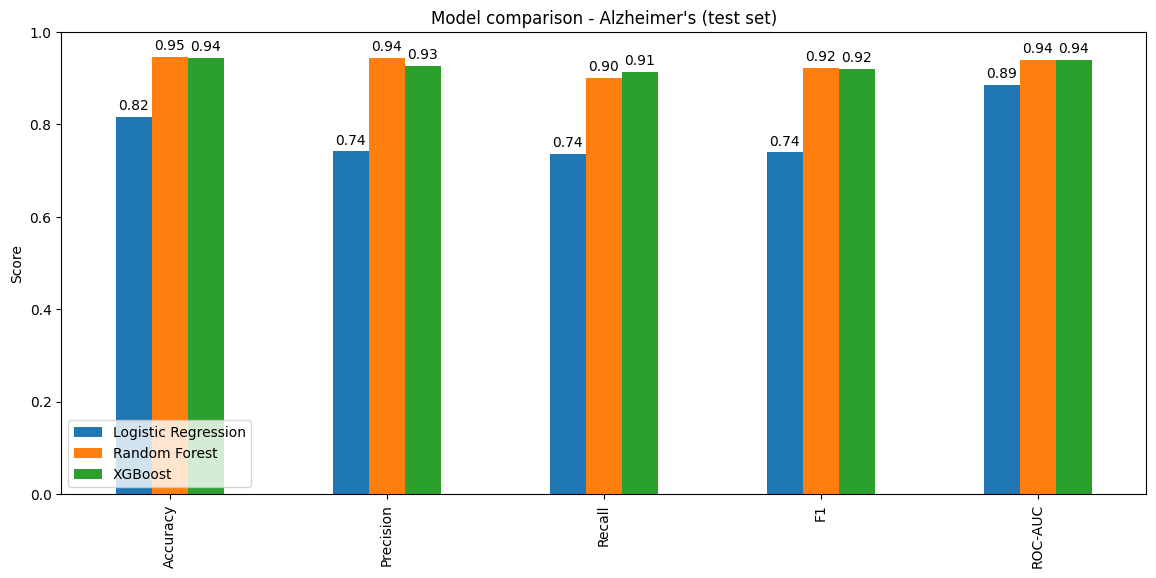

In [46]:
# Visualizing evaluation metrics for Alzheimer's
alz_comp = pd.DataFrame(results_alz)

ax = alz_comp.plot(kind='bar', figsize=(14, 6), ylim=(0, 1))
for container in ax.containers:
    ax.bar_label(container, fmt='{:.2f}', padding=3)
ax.set_ylabel('Score')
ax.set_title('Model comparison - Alzheimer\'s (test set)')
plt.show()

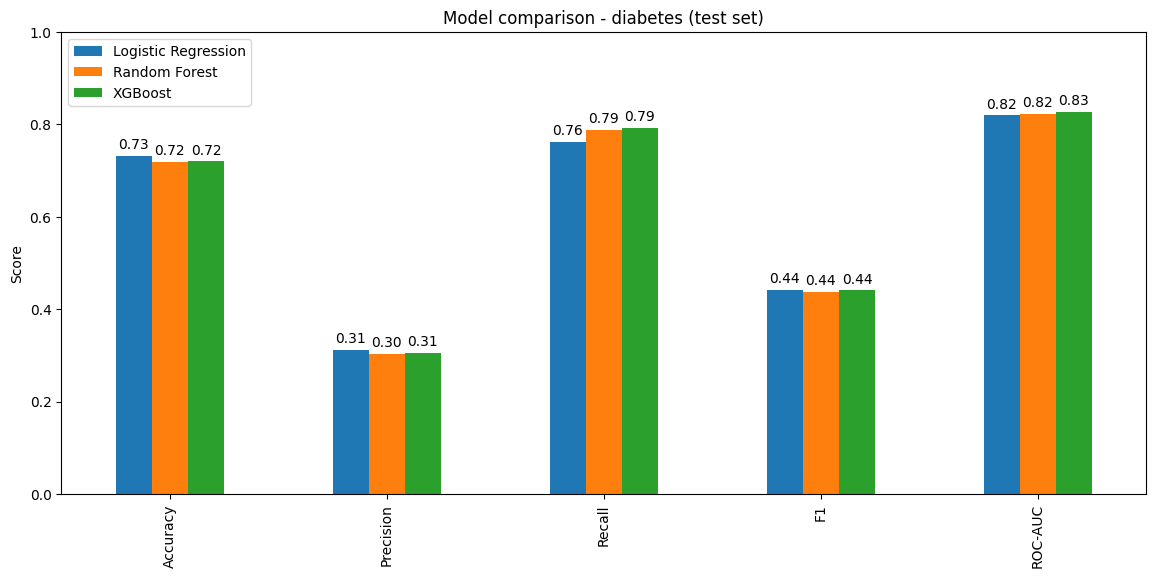

In [47]:
# Visualizing evaluation metrics for diabetes
dia_comp = pd.DataFrame(results_dia)

ax = dia_comp.plot(kind='bar', figsize=(14, 6), ylim=(0, 1))
for container in ax.containers:
    ax.bar_label(container, fmt='{:.2f}', padding=3)
ax.set_ylabel('Score')
ax.set_title('Model comparison - diabetes (test set)')
plt.show()

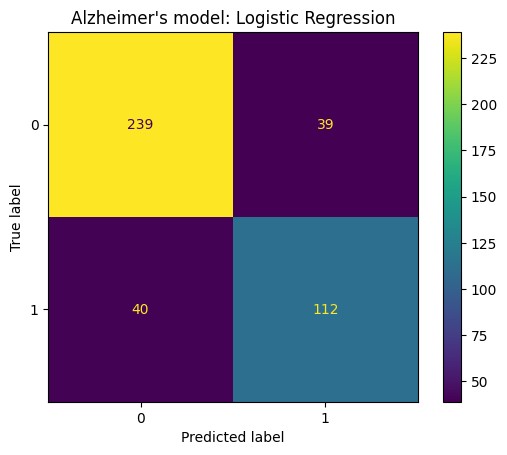

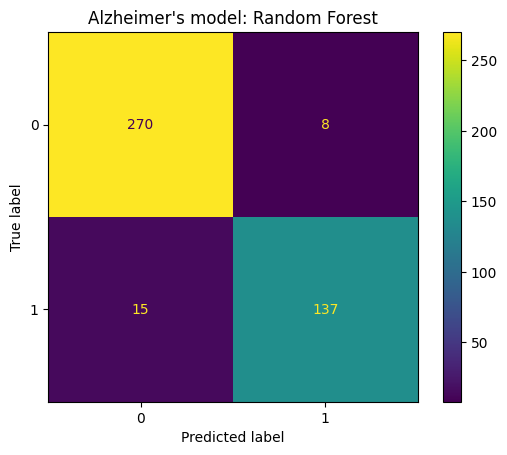

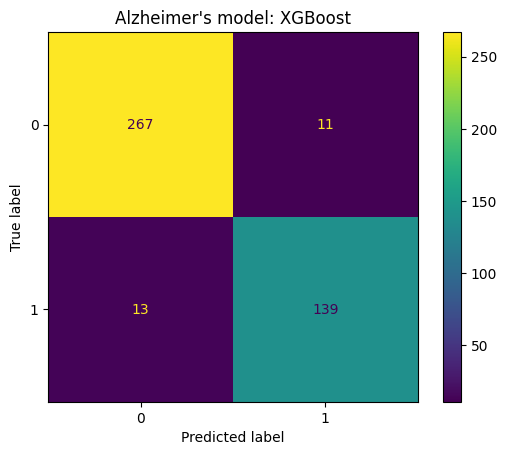

In [33]:
# Visualizing confusion matrix for Alzheiemr's
for name, model in best_alz.items():
    cm = confusion_matrix(y_test_alz, model.predict(X_test_alz))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot()
    plt.title(f"Alzheimer's model: {name}")
    plt.show()


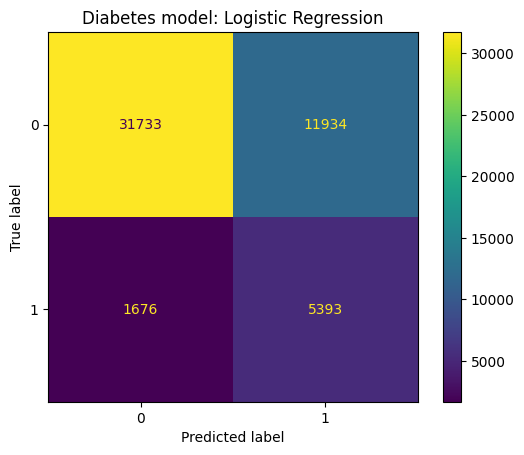

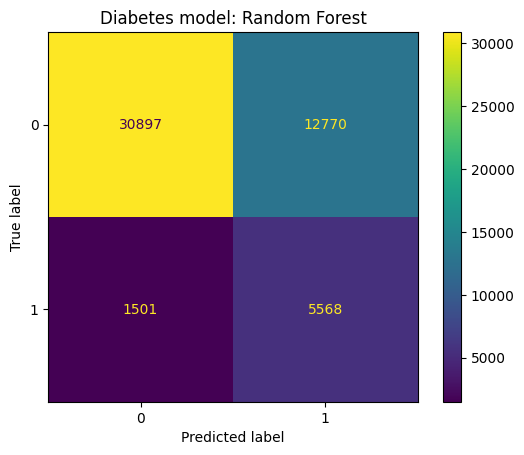

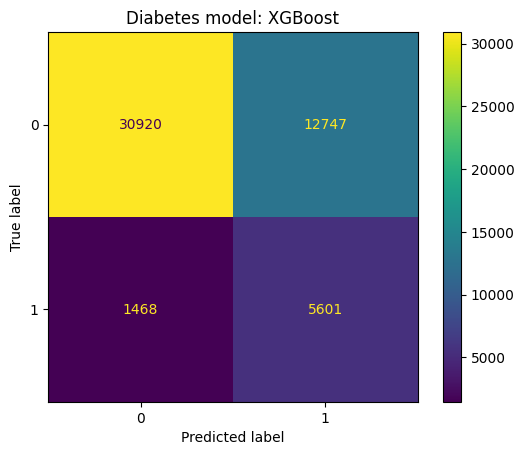

In [34]:
# Visualizing confusion matrix for diabetes
for name, model in best_dia.items():
    cm = confusion_matrix(y_test_dia, model.predict(X_test_dia))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot()
    plt.title(f"Diabetes model: {name}")
    plt.show()

In [35]:
# Roc curve plot function
def plot_roc_curve(y_true, y_proba, label):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y_true, y_proba):.2f})")

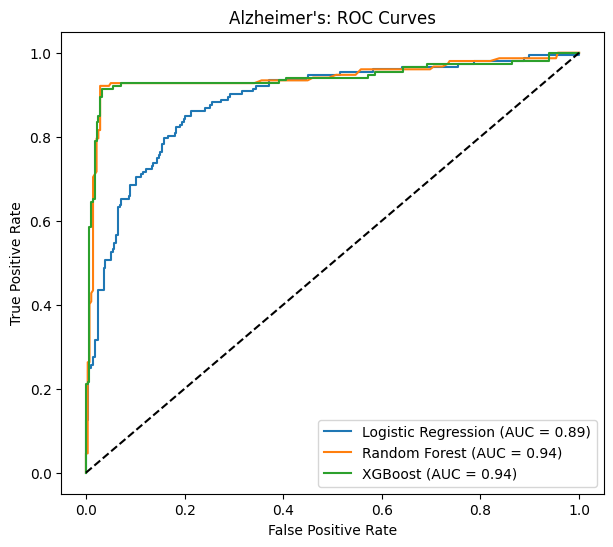

In [36]:
# Alzheimer's models ROC curves
plt.figure(figsize=(7, 6))

for name, model in best_alz.items():
    y_proba = model.predict_proba(X_test_alz)[:, 1]
    plot_roc_curve(y_test_alz, y_proba, name)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Alzheimer's: ROC Curves")
plt.legend()
plt.show()


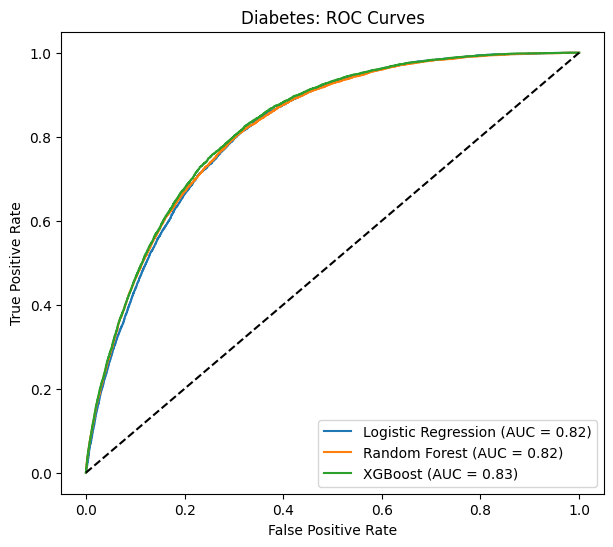

In [37]:
# Diabetes models ROC curves
plt.figure(figsize=(7, 6))

for name, model in best_dia.items():
    y_proba = model.predict_proba(X_test_dia)[:, 1]
    plot_roc_curve(y_test_dia, y_proba, name)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Diabetes: ROC Curves")
plt.legend()
plt.show()


In [38]:
# Feature importance for Alzheimer's models
LR = best_alz['Logistic Regression']
coefs_LR = pd.Series(LR.coef_[0], index=alz_features).sort_values(ascending=False)
print("Logistic Regression coefficients")
print(coefs_LR)

RF = best_alz['Random Forest']
importances_RF = pd.Series(RF.feature_importances_, index=alz_features).sort_values(ascending=False)
print("\nRandom Forest importances")
print(importances_RF)

XGB = best_alz['XGBoost']
importances_XGB = pd.Series(XGB.feature_importances_, index=alz_features).sort_values(ascending=False)
print("\nXGBoost importances")
print(importances_XGB)

Logistic Regression coefficients
MemoryComplaints             1.152221
BehavioralProblems           0.941573
CholesterolHDL               0.151970
CholesterolTriglycerides     0.107056
DifficultyCompletingTasks    0.097841
Hypertension                 0.097052
CardiovascularDisease        0.081805
DiastolicBP                  0.055860
CholesterolTotal             0.039657
Diabetes                     0.022303
Depression                   0.021573
DietQuality                  0.005253
Gender                      -0.001718
BMI                         -0.009107
Disorientation              -0.016706
Forgetfulness               -0.027495
Ethnicity                   -0.038400
PhysicalActivity            -0.038755
Confusion                   -0.039521
AlcoholConsumption          -0.041037
Smoking                     -0.056785
FamilyHistoryAlzheimers     -0.065975
EducationLevel              -0.066589
SystolicBP                  -0.067606
PersonalityChanges          -0.068462
SleepQuality     

In [39]:
# Feature importance for diabetes models
LR = best_dia['Logistic Regression']
coefs_LR = pd.Series(LR.coef_[0], index=dia_features).sort_values(ascending=False)
print("Logistic Regression coefficients")
print(coefs_LR)

RF = best_dia['Random Forest']
importances_RF = pd.Series(RF.feature_importances_, index=dia_features).sort_values(ascending=False)
print("\nRandom Forest importances")
print(importances_RF)

XGB = best_dia['XGBoost']
importances_XGB = pd.Series(XGB.feature_importances_, index=dia_features).sort_values(ascending=False)
print("\nXGBoost importances")
print(importances_XGB)

Logistic Regression coefficients
GenHlth                 0.652747
BMI                     0.525057
Age                     0.424645
HighBP                  0.365408
HighChol                0.293168
CholCheck               0.210098
Sex                     0.127953
HeartDiseaseorAttack    0.091227
Stroke                  0.055556
DiffWalk                0.040563
NoDocbcCost             0.018160
Smoker                  0.012864
AnyHealthcare           0.010432
Veggies                 0.000593
PhysActivity           -0.025782
Fruits                 -0.036618
Education              -0.038854
MentHlth               -0.063790
PhysHlth               -0.067956
Income                 -0.128373
HvyAlcoholConsump      -0.150889
dtype: float64

Random Forest importances
GenHlth                 0.232160
HighBP                  0.204600
BMI                     0.135241
Age                     0.098101
HighChol                0.093871
DiffWalk                0.051518
Income                  0.034896
P

In [40]:
def plot_importance(name, model, feature_names, dataset_label, top_n=10):
    if name == 'Logistic Regression':
        values = pd.Series(model.coef_[0], index=feature_names)
        top = values.reindex(values.abs().sort_values(ascending=False).index).head(top_n)
    else:
        values = pd.Series(model.feature_importances_, index=feature_names)
        top = values.sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(8, 5))
    plt.barh(top.index, top.values)
    plt.title(f"{dataset_label}: {name} top 10 features")
    plt.gca().invert_yaxis()
    plt.show()

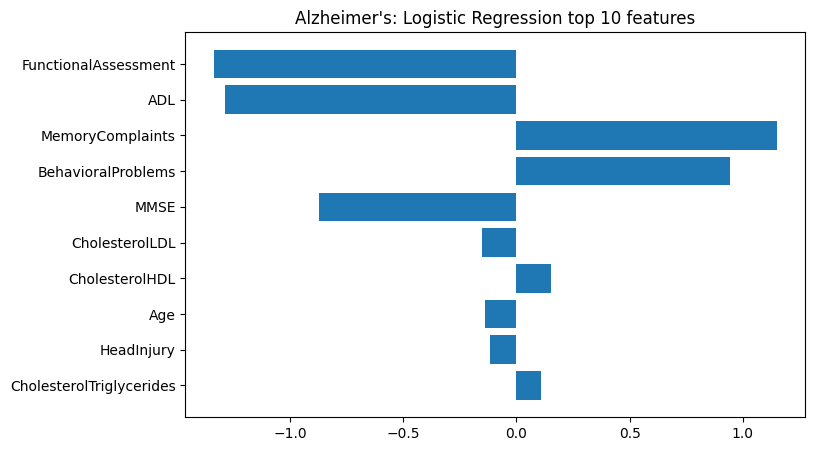

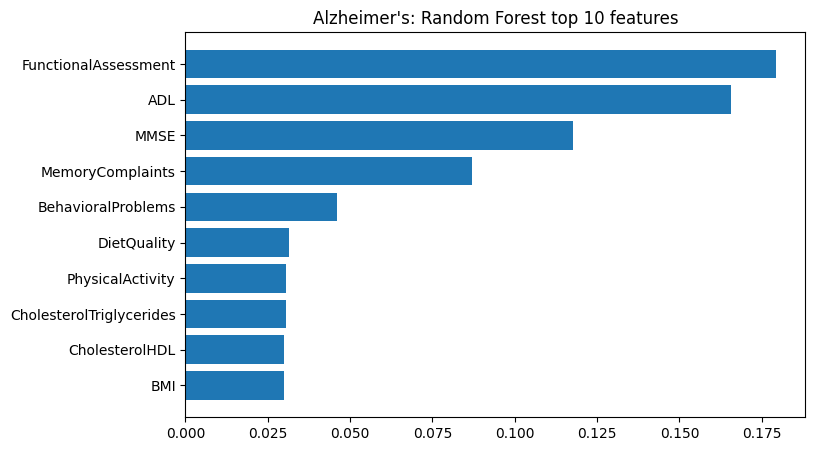

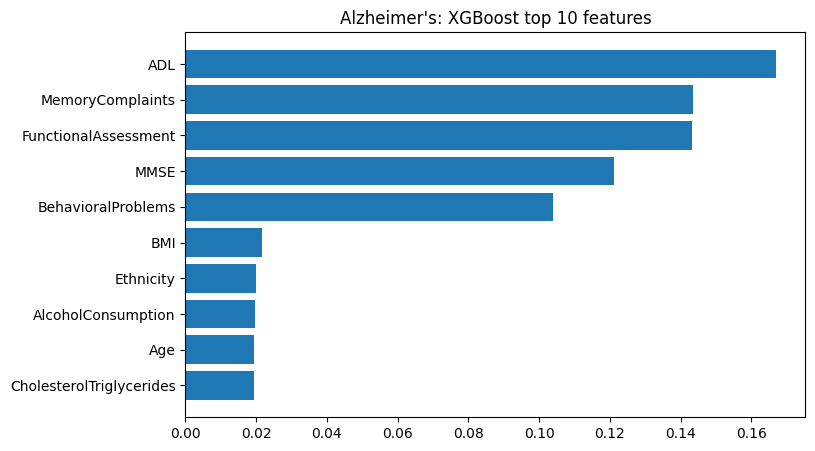

In [41]:
for name, model in best_alz.items():
    plot_importance(name, model, alz_features, "Alzheimer's")

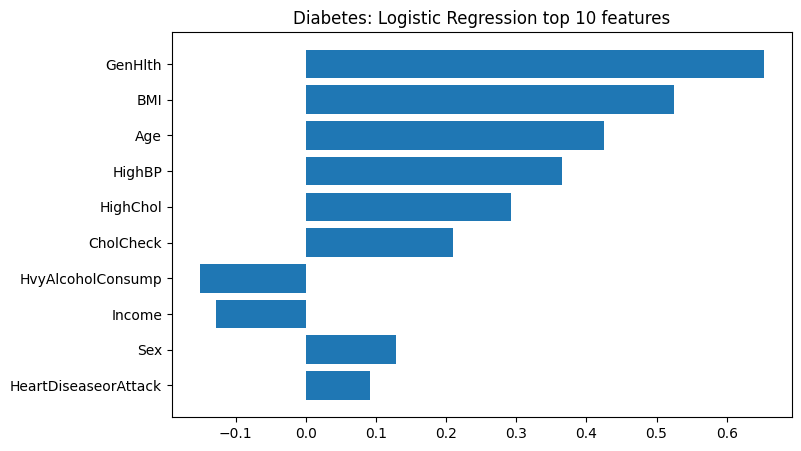

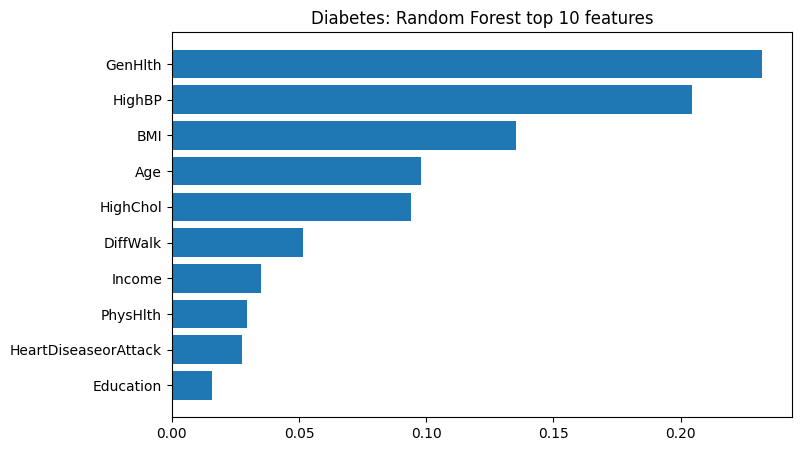

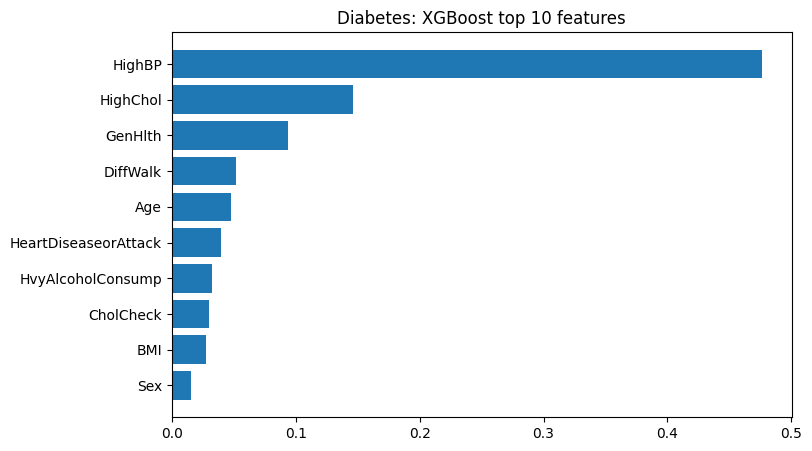

In [42]:
for name, model in best_dia.items():
    plot_importance(name, model, dia_features, "Diabetes")